# Homework10

Exercises with text processing and NLP modeling

## Goals

- Understand similarities and differences between the processes of working with text, images and tabular data
- Practice with different methods of encoding and modeling text data
- See different methods for extracting information or patterns from text datasets

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [1]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/text_utils.py

In [2]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from data_utils import display_silhouette_plots, object_from_json_url
from text_utils import get_top_words

You can tell it's gonna be a good homework from the number of imports.
# 🙃

## Cheat Sheet

There are lots of conversions in this homework between lists, strings, vectors, scores, etc...

This list can help as a quick reference for the names of the functions and what they expect as input, and produce as output.

These all operate on lists of _something_ and return lists of _something else_. But, here, let's just focus on the _type_ of the elements that go in these lists. Most of them will work on single elements, but not all.

`TFIDF.fit_transform(string)` / `TFIDF.transform(string)` : string -> sparse vector

`TFIDF.inverse_transform(vector)` : sparse vector -> list of words (NOT a string)

`TFIDF.get_feature_names_out()` : None -> list of words (vocab of dataset)

`TFIDF.get_feature_names_out()[idx]` : int (column index / word id) -> word

`vector.toarray()` : vector -> regular array

`get_top_words(vector, vocab, n_words=N)` : vector + list of all words + int -> list of top-N words in vector

`argsort(metric)` : list of floats -> list of int indexes

For example:

To get the words in a sentence ordered by importance (most important first), we have to turn a string into a vector, then the vector into a regular list of scores, then the list into indexes, and, finally, fetch words from our vocab list using these indexes.

```py
sentence = "a sentence goes here"
num_words = len(sentence.split(" "))
sentence_vct = TFIDF.transform([sentence])
sentence_vct_list = sentence_vct.toarray()
idx_by_importance = argsort(sentence_vct_list, reverse=True)[:num_words]
TFIDF.get_feature_names_out()[idx_by_importance]
```

For this particular example we could've used the `get_top_words()` function to get words ordered by importance:

```py
sentence = "a sentence goes here"
num_words = len(sentence.split(" "))

get_top_words(
  TFIDF.transform([sentence]),
  TFIDF.get_feature_names_out(),
  n_words=num_words
)
```

## Have protein, need seasoning

Let's create a model to help us season our foods. In the end, what we want is a model that receives a short list of ingredients and returns a list of seasonings or complementary ingredients for our original ingredients list.

In order to do that we need a dataset of recipes. We'll load that into a text dataset where each recipe is a document and the ingredients are our document *tokens*.

Let's take a look at the recipe dataset and become familiar with the data and how it's organized.

We'll load our recipes and do a bit of exploratory data analysis to look for patterns first to see if this kind of modeling makes any sense.

### Load Data

Here's our dataset. Let's load it into an object for inspection:

In [3]:
DATA_PATH = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/refs/heads/main/datasets/text/recipes/recipes_min16.json"
recipes_obj = object_from_json_url(DATA_PATH)

### Look at Data

How's the data organized?

How many recipes do we have?

Do all recipes have the same number of ingredients?

Anything else stand out about the data?

In [4]:
# TODO: Look at Data here

print(recipes_obj)

# TODO: How many recipes

print(len(recipes_obj))

# TODO: How many ingredients do the shortest and longest recipes have?

longest_recipe = recipes_obj[0]
shortest_recipe = recipes_obj[0]

for recipe in recipes_obj:
  if len(recipe["ingredients"]) > len(longest_recipe["ingredients"]):
    longest_recipe = recipe
  if len(recipe["ingredients"]) < len(shortest_recipe["ingredients"]):
    shortest_recipe = recipe
  
print(len(longest_recipe["ingredients"]))
print(len(shortest_recipe["ingredients"]))


[{'id': 18009, 'ingredients': ['raisins', 'baking powder', 'egg', 'sugar', 'milk', 'flour']}, {'id': 35687, 'ingredients': ['parmesan cheese', 'salt', 'cornmeal', 'black pepper', 'sausage', 'olive oil', 'leeks', 'water']}, {'id': 38527, 'ingredients': ['salt', 'corn starch', 'butter', 'lemon juice', 'baking powder', 'heavy cream', 'peaches', 'sugar', 'flour']}, {'id': 41217, 'ingredients': ['corn starch', 'orange juice', 'rice', 'ginger', 'vinegar', 'vegetable oil', 'garlic', 'sriracha', 'sesame seeds', 'chicken broth', 'soy sauce', 'egg', 'onion', 'white pepper', 'orange zest', 'sugar']}, {'id': 42969, 'ingredients': ['cilantro', 'rice', 'ginger', 'garlic', 'yogurt', 'curry powder', 'onion', 'cumin']}, {'id': 44883, 'ingredients': ['mozzarella cheese', 'salt', 'parmesan cheese', 'rice', 'pasta', 'marinara sauce', 'basil']}, {'id': 19001, 'ingredients': ['salt', 'rice', 'chili', 'olives', 'jack cheese', 'cheddar cheese', 'water', 'sour cream']}, {'id': 16526, 'ingredients': ['salt', 'r

### Create Input Features

Our dataset doesn't really have to be a `DataFrame` here. It can, but it doesn't have to be.

Each recipe right now is described as a list of ingredients, but what we really want is a list of *sentences*, where each *sentence* is a Python `string` with all of the ingredients for a given recipe.

Instead of:<br>```["salt", "baking soda", "water", "mushroom"]```,

we want:<br>```"salt baking soda water mushroom"```

The `join()` function might help.

Another thing to consider is wether we want to do anything special about multi-word ingredients, like *baking soda*.

Do we want to let our vectorizer split that into two tokens, or do we want to guarantee that *baking* and *soda* always stay together? 

In [5]:
# TODO: turn list of objects into list of strings

import re

ingredient_strings = []

for recipe in recipes_obj:
  raw_str = ", ".join(recipe["ingredients"])
  ind_str = re.sub(r'(\b\w+)\s(\w+),', r'\1_\2,', raw_str)
  ingredient_strings.append(ind_str)

print(ingredient_strings[:3])

['raisins, baking_powder, egg, sugar, milk, flour', 'parmesan_cheese, salt, cornmeal, black_pepper, sausage, olive_oil, leeks, water', 'salt, corn_starch, butter, lemon_juice, baking_powder, heavy_cream, peaches, sugar, flour']


### Encode Data

The fun part.

Let's vectorize our list of ingredient strings into a sparse document matrix using `CountVectorizer` or `TfidfVectorizer`.

The resulting matrix will have one row for each recipe, and the columns will encode the ingredients.

In [6]:
# TODO: Vectorize ingredients from our recipe list

count_vectorizer = CountVectorizer()

word_count = count_vectorizer.fit_transform(ingredient_strings)
print(count_vectorizer.get_feature_names_out())
print(word_count.toarray())


['adobo_sauce' 'agave_nectar' 'allspice' 'almond' 'amchur' 'american'
 'american_cheese' 'ancho' 'ancho_powder' 'anchovy' 'anchovy_paste'
 'andouille' 'angel_hair' 'anise' 'apple' 'apple_juice' 'apples' 'apricot'
 'artichoke' 'artichokes' 'arugula' 'asafoetida' 'asiago' 'asian'
 'asparagus' 'avocado' 'bacon' 'baguette' 'baking_powder' 'baking_soda'
 'bamboo_shoots' 'bananas' 'basil' 'bay' 'bean' 'bean_sprouts' 'beans'
 'beansprouts' 'beef' 'beef_broth' 'beef_stock' 'beef_tenderloin' 'beer'
 'beets' 'bell_pepper' 'belly' 'bird_chile' 'biscuits' 'black'
 'black_bean' 'black_pepper' 'blackberries' 'blueberries' 'boiling_water'
 'bok_choy' 'bonito_flakes' 'bouillon' 'bourbon_whiskey' 'bow' 'brandy'
 'bread' 'bread_crumb' 'bread_flour' 'bread_rolls' 'breadcrumbs'
 'broccoli' 'broth' 'brown' 'butter' 'buttermilk' 'butternut'
 'butternut_squash' 'cabbage' 'cachaca' 'cake' 'cake_flour'
 'cannellini_beans' 'canola' 'canola_oil' 'capers' 'caraway_seeds'
 'cardamom' 'cardamom_pods' 'carrots' 'cas

In [7]:
tfidf_vectorizer = TfidfVectorizer()

word_freq = tfidf_vectorizer.fit_transform(ingredient_strings)

print(tfidf_vectorizer.get_feature_names_out())
print(word_freq.toarray())

['adobo_sauce' 'agave_nectar' 'allspice' 'almond' 'amchur' 'american'
 'american_cheese' 'ancho' 'ancho_powder' 'anchovy' 'anchovy_paste'
 'andouille' 'angel_hair' 'anise' 'apple' 'apple_juice' 'apples' 'apricot'
 'artichoke' 'artichokes' 'arugula' 'asafoetida' 'asiago' 'asian'
 'asparagus' 'avocado' 'bacon' 'baguette' 'baking_powder' 'baking_soda'
 'bamboo_shoots' 'bananas' 'basil' 'bay' 'bean' 'bean_sprouts' 'beans'
 'beansprouts' 'beef' 'beef_broth' 'beef_stock' 'beef_tenderloin' 'beer'
 'beets' 'bell_pepper' 'belly' 'bird_chile' 'biscuits' 'black'
 'black_bean' 'black_pepper' 'blackberries' 'blueberries' 'boiling_water'
 'bok_choy' 'bonito_flakes' 'bouillon' 'bourbon_whiskey' 'bow' 'brandy'
 'bread' 'bread_crumb' 'bread_flour' 'bread_rolls' 'breadcrumbs'
 'broccoli' 'broth' 'brown' 'butter' 'buttermilk' 'butternut'
 'butternut_squash' 'cabbage' 'cachaca' 'cake' 'cake_flour'
 'cannellini_beans' 'canola' 'canola_oil' 'capers' 'caraway_seeds'
 'cardamom' 'cardamom_pods' 'carrots' 'cas

In [8]:

# TODO: How many words are in our vocabulary?

# print(len(count_vectorizer.get_feature_names_out()))

print(len(tfidf_vectorizer.get_feature_names_out()))

576


### Cluster Data

Now that we have our recipes/documents vectorized we can study them a little bit, and look for patterns.

What happens if we cluster our recipes ? What do the cluster centers represent ?

When might this be useful ?

In [9]:
# TODO: cluster recipes

In [10]:
# TODO: cluster recipes

count_vocab = count_vectorizer.get_feature_names_out()

k = 8

food_clusters = KMeans(n_clusters=k, random_state=800)
food_km = food_clusters.fit_predict(word_count)

food_clusters.cluster_centers_

food_clusters.cluster_centers_.shape

get_top_words(food_clusters.cluster_centers_, count_vocab, n_words=8)




[['salt', 'pepper', 'onion', 'garlic', 'butter', 'rice', 'egg', 'flour'],
 ['salt',
  'sugar',
  'black_pepper',
  'garlic',
  'water',
  'butter',
  'rice',
  'parmesan_cheese'],
 ['egg',
  'flour',
  'salt',
  'sugar',
  'butter',
  'milk',
  'baking_powder',
  'vanilla'],
 ['onion',
  'salt',
  'garlic',
  'cilantro',
  'chili',
  'cumin',
  'tomatoes',
  'ginger'],
 ['garlic',
  'olive_oil',
  'salt',
  'onion',
  'black_pepper',
  'tomatoes',
  'parsley',
  'rice'],
 ['soy_sauce',
  'garlic',
  'sugar',
  'onion',
  'ginger',
  'rice',
  'sesame_oil',
  'vinegar'],
 ['onion',
  'tortilla',
  'rice',
  'tomatoes',
  'cilantro',
  'cheddar_cheese',
  'chili',
  'salsa'],
 ['oil',
  'olive',
  'garlic',
  'salt',
  'tomatoes',
  'onion',
  'parmesan_cheese',
  'black_pepper']]

In [11]:

tfidf_vocab = count_vectorizer.get_feature_names_out()

k = 4

food_clusters = KMeans(n_clusters=k, random_state=800)
food_km = food_clusters.fit_predict(word_freq)

food_clusters.cluster_centers_

food_clusters.cluster_centers_.shape


(4, 576)

### Cluster Centers

Use the `get_top_words()` function to decode the `cluster_centers` back into ingredients.

In [12]:
# TODO: Look at cluster centers

get_top_words(food_clusters.cluster_centers_, tfidf_vocab, n_words=8)

[['soy_sauce',
  'sugar',
  'ginger',
  'sesame_oil',
  'vinegar',
  'garlic',
  'rice',
  'onion'],
 ['garlic',
  'salt',
  'olive_oil',
  'onion',
  'black_pepper',
  'tomatoes',
  'parmesan_cheese',
  'parsley'],
 ['flour',
  'egg',
  'sugar',
  'butter',
  'milk',
  'salt',
  'baking_powder',
  'vanilla'],
 ['cilantro',
  'chili',
  'onion',
  'cumin',
  'tortilla',
  'tomatoes',
  'salt',
  'garlic']]

### Interpretation

<span style="color:hotpink">
What do these cluster centers represent ?<br>
Is there anything interesting about recipe cluster centers ?<br>
</span>

<span style="color:hotpink;">

the tfidf one's first ingredient in each cluster is sort of the signature ingredeitns for it. you can maybe find like ingredients of a vibe or maybe type of cooking, like if there was a alot of olive oil in the basis of a certain cuisine, or the inclusion of chili. it will weight out ingredients that are maybe 'not important' like salt which most things probably has. 

the counts one has just counts of highest ingredients and the more common ingredients might become dominant in the cluster. 

</span>

### Plot Clusters

Let's plot our clusters to see if we have to adjust any of the clustering parameters.

Since we can't plot in $500$ dimensions, we should use `TruncatedSVD` to look at our clusters in $2D$ and $3D$.

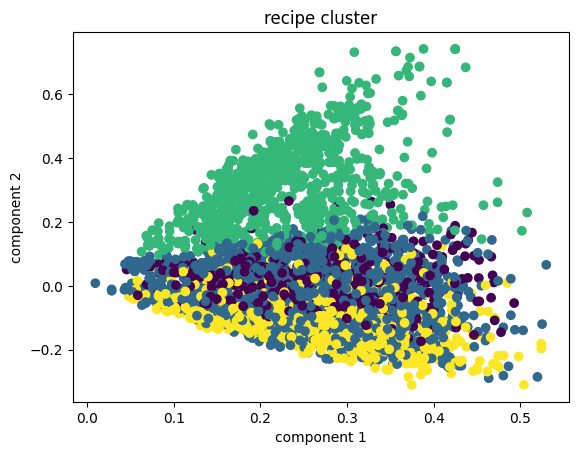

Component 0: ['tomatoes', 'rice', 'garlic', 'onion', 'salt']
Component 1: ['sugar', 'milk', 'butter', 'egg', 'flour']


In [13]:
# TODO: TruncatedSVD to reduce the dimensions of our feature space

two_d = TruncatedSVD(n_components=2, random_state=1010)
small_two_d = two_d.fit_transform(word_freq) 

small_two_d[:5]

plt.scatter(
    small_two_d[:, 0],
    small_two_d[:, 1],
    c=food_km
)
plt.xlabel("component 1")
plt.ylabel("component 2")
plt.title("recipe cluster")
plt.show()

# looked this up to try to understand better:
terms = tfidf_vectorizer.get_feature_names_out()

for i, comp in enumerate(two_d.components_):
    top_words = comp.argsort()[-5:]
    print(f"Component {i}: {[terms[j] for j in top_words]}")


### Interpretation

<span style="color:hotpink">
What does the graph look like ?<br>
Are the clusters well-separated ?
</span>

<span style="color:hotpink;">
it's not super separated by the clusters... I think this makes sense because a lot of recipes will share and overlap ingredients even if different recipes. like, probably everyone uses salt. perhaps it should be cluster way less though. 
</span>

### Plot Silhouette Plots

We can also check the quality of our clustering by looking at the silhouette plots that we get from calling:<br>
`display_silhouette_plots(vectors, clusters)`.

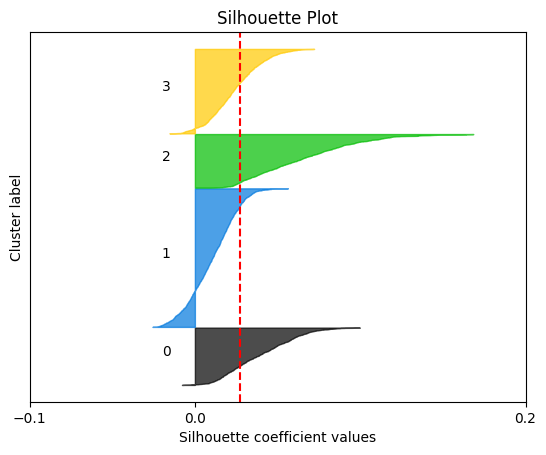

In [14]:
display_silhouette_plots(word_freq, food_km)

### Interpretation

<span style="color:hotpink">
How many clusters did you end up with ?<br>
How do they look ?<br>
</span>

<span style="color:hotpink;">

I have 8 clusters and they do not look good </3

a bunch of clusters are dipped to the left, but 2 and 6 have some points on the right.
the silhouette score is super low...

I am going to try with smaller k! => 
  okay, I tried with just 4 clusters and think it is more meaningful. the clusters are a littler more separate and the silhouette score is not as low anymore. 

>
</span>

## Recipe Completion

Ok. On to the main event.

Let's create some recipes.

We'll do this using a technique similar to what is used for movie/product recommendations. Given an initial set of ingredients, we'll look at recipes that have similar ingredients and "recommend" additional ingredients.

We already have all of the recipes in our dataset encoded as `tf-idf` vectors. The rest of our algorithm will be something like:
1. Start with an initial set of ingredients
2. Encode ingredients
3. Find a set of recipes that are similar to our list of ingredients
4. Find common ingredients that are in the similar recipes, but not in our list of ingredients
5. Pick representative ingredient to add to recipe
6. Repeat

Let's start.

### 1. Initial list of ingredients

This is just a string with ingredients:

In [15]:
recipe_seed_str = "tofu butter sugar cilantro salt"

### 2. Encode ingredients

Transform the string into a `tf-idf` vector using the `transofrm()` function from the pre-fitted `TfidfVectorizer` object:

In [16]:
# TODO: transform string into sparse vector

recipe_seed_vct = tfidf_vectorizer.transform([recipe_seed_str])


### 3. Find similar recipes

The meat of the algorithm. No pun intended.

In order to find similar recipes, we'll first calculate the distance between our current list of ingredients and all recipes in our dataset.

We can start with euclidean distance and later try other kinds, but the overall processing will be the same:

1. Start with an empty list to store distances
2. Loop over the `tf-idf` recipe vectors and for each vector:
   1. Subtract the ingredient list
   2. Square the difference (to square a sparse matrix `A`, use `A.multiply(A)`)
   3. Sum the terms of the result
   4. Take the square root of the sum
   5. Append to distance list
3. Find the indices of the smallest distances (this operation is called `argsort` and will give us the indices of the recipes that are most similar to our list of ingredients)
4. Check the recipes to see if they are indeed similar (`inverse_transform()` the vectors at the indices calculated above)

In [17]:
# argsort a list (get sequence of indices that would sort the list)
# https://stackoverflow.com/a/3382369
def argsort(L, reverse=False):
  L = L[0] if len(L) == 1 else L
  return sorted(range(len(L)), key=L.__getitem__, reverse=reverse)

In [18]:
# TODO: list to keep distances
recipe_distances = []

# TODO: loop over vectors and append euclidean distances to list

for i in range(word_freq.shape[0]):
  recipe_vector = word_freq[i]

  difference = recipe_vector - recipe_seed_vct
  square = difference.multiply(difference)
  distance = (square.sum()) ** 0.5
  
  recipe_distances.append(distance)

# TODO: argsort list of distances to find indices of similar recipes

index_sort = argsort(recipe_distances)

# TODO: check first 4 recipes

for i in index_sort[:4]:
  print(tfidf_vectorizer.inverse_transform(word_freq[i]))

[array(['salt', 'black_pepper', 'butter', 'garlic', 'onion', 'cilantro',
       'curry_powder', 'canola_oil', 'coconut_milk', 'tofu'], dtype='<U20')]
[array(['sugar', 'garlic', 'sesame_seeds', 'soy_sauce', 'scallions',
       'sesame_oil', 'red_pepper', 'tofu'], dtype='<U20')]
[array(['sugar', 'salt', 'soy_sauce', 'chili', 'sauce', 'cooking_oil',
       'tofu', 'chives'], dtype='<U20')]
[array(['sugar', 'salt', 'ginger', 'garlic', 'onion', 'cilantro',
       'mushrooms', 'rice_paper', 'lettuce', 'sunflower_oil', 'tofu'],
      dtype='<U20')]


### 4. Find ingredients to recommend

We have a way to get a set of similar recipes with similar ingredients, and now want to find a *meaningful*, or *representative*, ingredient to add to our ingredients list.

Let's consider ingredients in the $16$ most similar recipes. What we are trying to do is find an ingredient that is in a lot of these recipes, but not yet in our list of ingredients.

There are many possible ways of doing this. We could count the number of times different ingredients show up in these $16$ recipes using Python dictionaries and/or sets, but what we're trying to do here is very similar to what a `TfidfVectorizer` does: calculate relative importance of terms in a series of documents.

Let's re-encode these $16$ recipes using their own separate `TfidfVectorizer`, then sum the importance of each ingredient and look at ingredients with the highest importance scores.

We could re-use the vectors/scores from the original `TfidfVectorizer`, but they're gonna be influenced by the relative frequencies of all of the ingredients that showed up in all of the recipes. Using a separate vectorizer is a little bit more precise.

The steps we need to take are:

1. Separate the $16$ recipes most similar to our list of ingredients
   1. We have lots of representations of our recipes, but `recipes` (list of strings) might be the easiest one to use here
2. Create a new `TfidfVectorizer` and encode the $16$ recipes
3. Sum the resulting vectors by column to get overall importance scores for each ingredient/token
4. Convert resulting vector to a list using `A.tolist()[0]`
5. `argsort` the importance scores to get sequence of ingredient indices ordered from most to least important
6. Find the most important ingredient that isn't on the ingredient list

In [24]:
# TODO: Get 16 most similar recipes

index_top_16 = index_sort[:16]

# TODO: Encode the 16 recipes

top_16_recipes = [ingredient_strings[i] for i in index_top_16]
new_vectorizer = TfidfVectorizer()
top_16_matrix = new_vectorizer.fit_transform(top_16_recipes)

# TODO: Sum the recipe vectors by column to get ingredient importance scores

importance = top_16_matrix.sum(axis=0)

# TODO: Convert sparse vector to regular list with A.tolist()[0]

importance_list = importance.tolist()[0]

# TODO: argsort the importance scores

importance_idx = argsort(importance_list, reverse=True)

# TODO: Find most important ingredient not yet on the list of ingredients

seed_set = set(recipe_seed_str.split())
vocab = tfidf_vectorizer.get_feature_names_out()

for idx in importance_idx:
    ingredient = vocab[idx]
    if ingredient not in seed_set:
        print(ingredient)

bread
asparagus
beef_broth
bourbon_whiskey
bonito_flakes
black_bean
apple
asian
broccoli
angel_hair
asiago
bread_rolls
avocado
beef_stock
belly
ancho_powder
blackberries
amchur
breadcrumbs
apples
bread_flour
boiling_water
american
apricot
apple_juice
bird_chile
bay
beansprouts
basil
brown
bok_choy
anise
black_pepper
american_cheese
asafoetida
beer
almond
andouille
beets
bell_pepper
bacon
baking_soda
artichoke
artichokes
beef
bean
bouillon
broth
agave_nectar
anchovy_paste
bean_sprouts
baking_powder
bread_crumb
bamboo_shoots
biscuits
brandy
bananas
beans
black
bow
adobo_sauce
ancho
anchovy
beef_tenderloin
arugula
baguette
allspice
blueberries


### 5. Add ingredient to recipe

This is simply adding a word to `recipe_seed_str`

In [28]:
# TODO: add the first important ingredient to list of ingredients

recommended_ingredient = "garlic"

recipe_seed_str += " " + recommended_ingredient 

print(recipe_seed_str)

tofu butter sugar cilantro salt garlic


### 6. Repeat (Optional)

Now we can repeat this process until we get an empty list of important ingredients: 
1. Encode current recipe
2. Find similar recipes
3. Find important ingredients
4. Add important ingredient

Might be helpful to define a couple of functions, like `find_similar_recipes()` and `find_important_ingredients()`...

Only do this step if you're really curious about experimenting with generating unconventional ingredient lists. It's not going to be graded.

In [29]:
# TODO: Create find_similar_recipes(ingredients, recipes, vectorizer)

def find_similar_recipes(ingredient_str, recipes_matrix, vectorizer):
    
    ingredient_vct = vectorizer.transform([ingredient_str])
    
    distances = []
    for i in range(recipes_matrix.shape[0]):
        diff = recipes_matrix[i] - ingredient_vct
        sq = diff.multiply(diff)
        distance = (sq.sum()) ** 0.5
        distances.append(distance)
    
    return argsort(distances)

# TODO: Create find_important_ingredients(recipes)

def find_important_ingredients(seed_str, recipes_subset):
    
    vec = TfidfVectorizer()
    subset_matrix = vec.fit_transform(recipes_subset)

    importance = subset_matrix.sum(axis=0)
    importance_list = importance.tolist()[0]
    
    importance_idx = argsort(importance_list, reverse=True)
    
    seed_set = set(seed_str.split())
    vocab = vec.get_feature_names_out()
    
    for idx in importance_idx:
        ing = vocab[idx]
        if ing not in seed_set:
            return ing
    
    return None 

# TODO: Create recipe by repeating calls to find_similar_recipes() and find_important_ingredients()

recipe_seed_str = "tofu butter sugar cilantro salt"

max_iter = 5
for _ in range(max_iter):
    sorted_indices = find_similar_recipes(recipe_seed_str, word_freq, tfidf_vectorizer)
    
    top_recipes = [ingredient_strings[i] for i in sorted_indices[:16]]
    
    new_ing = find_important_ingredients(recipe_seed_str, top_recipes)
    
    if new_ing is None:
        break  # Nothing new to add
    
    recipe_seed_str += " " + new_ing
    print("Added:", new_ing)
    print("Current recipe:", recipe_seed_str)

Added: garlic
Current recipe: tofu butter sugar cilantro salt garlic
Added: soy_sauce
Current recipe: tofu butter sugar cilantro salt garlic soy_sauce
Added: scallions
Current recipe: tofu butter sugar cilantro salt garlic soy_sauce scallions
Added: ginger
Current recipe: tofu butter sugar cilantro salt garlic soy_sauce scallions ginger
Added: sesame_oil
Current recipe: tofu butter sugar cilantro salt garlic soy_sauce scallions ginger sesame_oil
